In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv(r'C:\Users\sandu\Downloads\Data Set For Task\1) iris.csv')
print(df.head())
print(df.shape)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)


In [3]:
# We remove species column because KMeans finds groups on its own
# without knowing the actual species labels
X = df.drop(columns=['species'])
print("Features used for clustering:")
print(X.head())

Features used for clustering:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data standardized successfully!")
print("First 3 rows after scaling:")
print(X_scaled[:3])

Data standardized successfully!
First 3 rows after scaling:
[[-0.90068117  1.03205722 -1.3412724  -1.31297673]
 [-1.14301691 -0.1249576  -1.3412724  -1.31297673]
 [-1.38535265  0.33784833 -1.39813811 -1.31297673]]


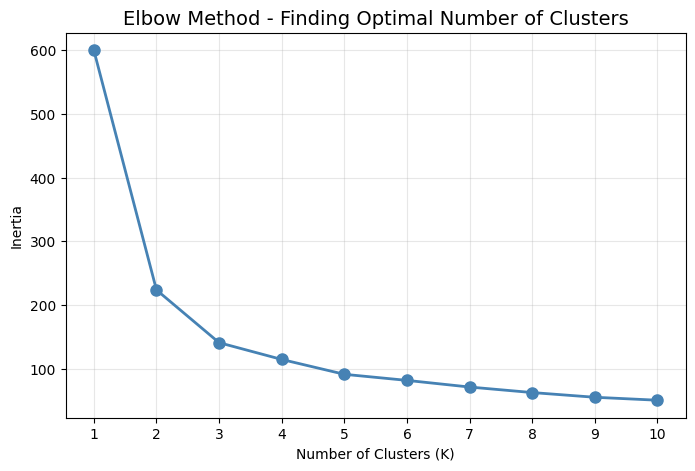

Elbow method chart saved!


In [9]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.title('Elbow Method - Finding Optimal Number of Clusters', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.savefig(r'C:\Users\sandu\Downloads\Intern - Codveda Technologies\Level 2\elbow_method.png')
plt.show()
print("Elbow method chart saved!")

In [10]:
# 3 clusters because elbow chart shows 3 is optimal
# Also we know iris has 3 species!
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster counts:")
print(df['cluster'].value_counts())

Cluster counts:
cluster
0    53
1    50
2    47
Name: count, dtype: int64


In [11]:
# 3 clusters because elbow chart shows 3 is optimal
# Also we know iris has 3 species!
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster counts:")
print(df['cluster'].value_counts())

Cluster counts:
cluster
0    53
1    50
2    47
Name: count, dtype: int64


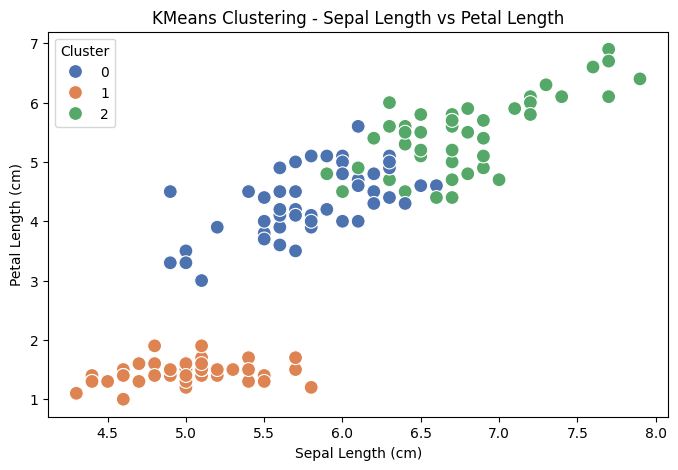

Cluster scatter plot saved!


In [15]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, 
                x='sepal_length', 
                y='petal_length', 
                hue='cluster',
                palette='deep',
                s=100)
plt.title('KMeans Clustering - Sepal Length vs Petal Length', fontsize=12)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.legend(title='Cluster')
plt.savefig(r'C:\Users\sandu\Downloads\Intern - Codveda Technologies\Level 2\clusters_scatter.png')
plt.show()
print("Cluster scatter plot saved!")

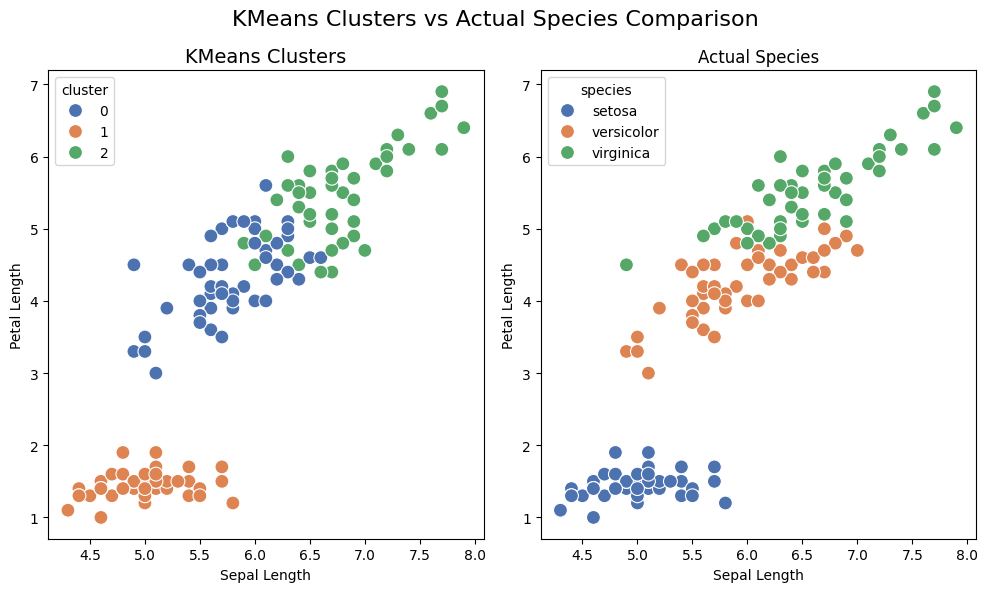

Comparison chart saved!


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# KMeans Clusters
sns.scatterplot(data=df,
                x='sepal_length',
                y='petal_length',
                hue='cluster',
                palette='deep',
                s=100,
                ax=axes[0])
axes[0].set_title('KMeans Clusters', fontsize=12+2)
axes[0].set_xlabel('Sepal Length')
axes[0].set_ylabel('Petal Length')

# Actual Species
sns.scatterplot(data=df,
                x='sepal_length',
                y='petal_length',
                hue='species',
                palette='deep',
                s=100,
                ax=axes[1])
axes[1].set_title('Actual Species', fontsize=12)
axes[1].set_xlabel('Sepal Length')
axes[1].set_ylabel('Petal Length')

plt.suptitle('KMeans Clusters vs Actual Species Comparison', fontsize=16)
plt.tight_layout()
plt.savefig(r'C:\Users\sandu\Downloads\Intern - Codveda Technologies\Level 2\clusters_vs_species.png')
plt.show()
print("Comparison chart saved!")